# Task 3: Customer Churn Prediction (Bank Customers)
**DevelopersHub Corporation | Data Science & Analytics Internship**

# **By: Muhammad Yahya Imran**

---

**Objective:** Identify customers who are likely to leave the bank.

**Dataset:** Churn Modelling Dataset (Kaggle)

**Steps:** Data Loading → Inspection → EDA → Preprocessing → Model Training → Evaluation → Conclusion

## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 110
print('Libraries imported successfully.')

Libraries imported successfully.


## Step 2: Load Dataset from Kaggle

In [2]:
# Uncomment below to install kagglehub if not already present
# !pip install kagglehub

import kagglehub
import os

path = kagglehub.dataset_download('shubh0799/churn-modelling')
print('Dataset downloaded to:', path)

csv_file = os.path.join(path, 'Churn_Modelling.csv')
df = pd.read_csv(csv_file)

print('Dataset Shape:', df.shape)
df.head(10)

100%|██████████| 262k/262k [00:00<00:00, 22.2MB/s]

Extracting files...
Dataset downloaded to: /root/.cache/kagglehub/datasets/shubh0799/churn-modelling/versions/1
Dataset Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


## Step 3: Dataset Inspection

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [5]:
print('Missing values:')
print(df.isnull().sum())

Missing values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


## Step 4: Exploratory Data Analysis (EDA)

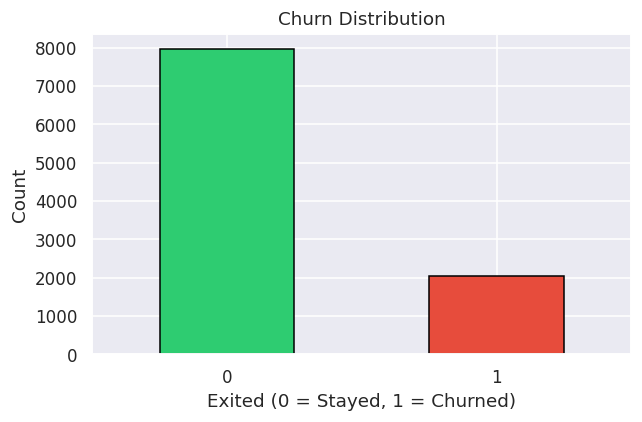

Churn rate: 20.37 %


In [6]:
# Show proportion of churned vs retained customers
plt.figure(figsize=(6, 4))
df['Exited'].value_counts().plot(kind='bar', color=['#2ECC71', '#E74C3C'], edgecolor='black')
plt.title('Churn Distribution')
plt.xlabel('Exited (0 = Stayed, 1 = Churned)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('Churn rate:', round(df['Exited'].mean() * 100, 2), '%')

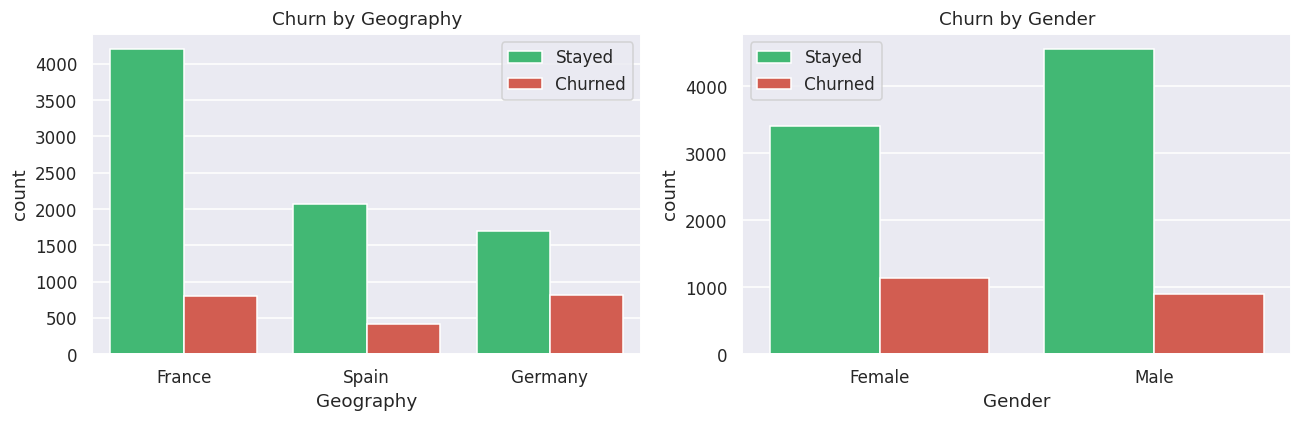

In [7]:
# Examine churn rates broken down by region and gender
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x='Geography', hue='Exited', ax=axes[0],
              palette={0: '#2ECC71', 1: '#E74C3C'})
axes[0].set_title('Churn by Geography')
axes[0].legend(['Stayed', 'Churned'])

sns.countplot(data=df, x='Gender', hue='Exited', ax=axes[1],
              palette={0: '#2ECC71', 1: '#E74C3C'})
axes[1].set_title('Churn by Gender')
axes[1].legend(['Stayed', 'Churned'])

plt.tight_layout()
plt.show()

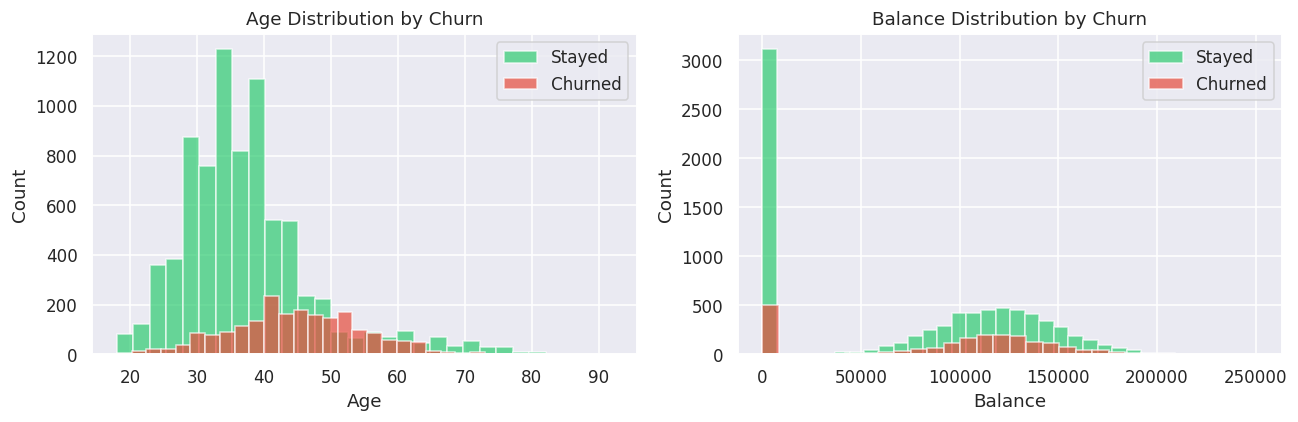

In [8]:
# Overlay histograms comparing age and balance by churn status
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df['Exited'] == 0]['Age'].hist(ax=axes[0], bins=30, alpha=0.7, color='#2ECC71', label='Stayed')
df[df['Exited'] == 1]['Age'].hist(ax=axes[0], bins=30, alpha=0.7, color='#E74C3C', label='Churned')
axes[0].set_title('Age Distribution by Churn')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

df[df['Exited'] == 0]['Balance'].hist(ax=axes[1], bins=30, alpha=0.7, color='#2ECC71', label='Stayed')
df[df['Exited'] == 1]['Balance'].hist(ax=axes[1], bins=30, alpha=0.7, color='#E74C3C', label='Churned')
axes[1].set_title('Balance Distribution by Churn')
axes[1].set_xlabel('Balance')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

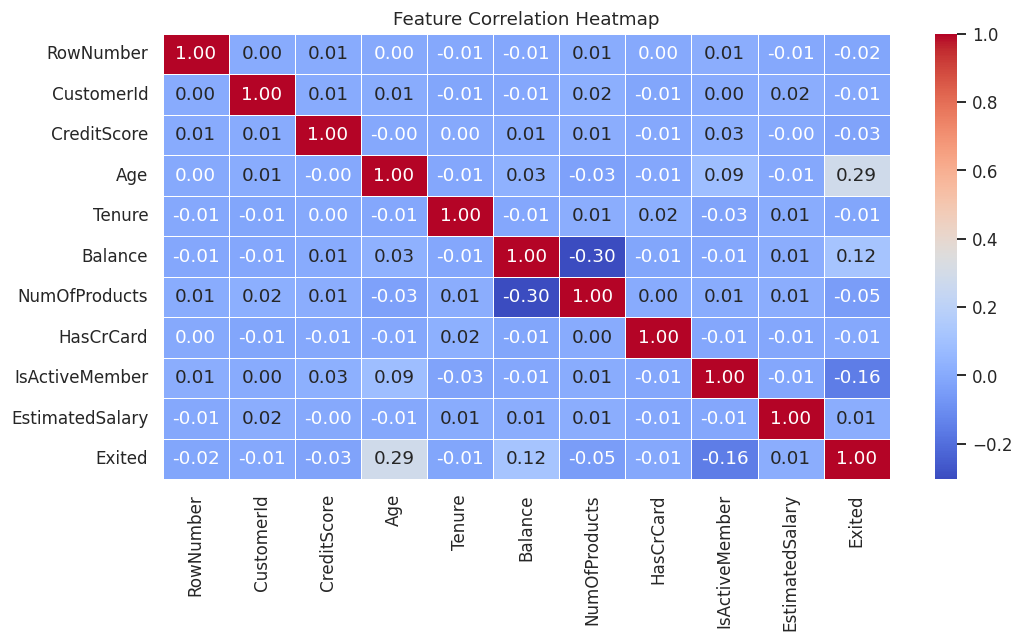

In [10]:
# Heatmap of pairwise feature correlations (numeric columns only)
plt.figure(figsize=(10, 6))
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## Step 5: Data Cleaning & Preprocessing

In [11]:
df_clean = df.copy()

# Remove columns that don't contribute to prediction
df_clean.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

# Encode Gender as a binary numeric variable
le = LabelEncoder()
df_clean['Gender'] = le.fit_transform(df_clean['Gender'])  # Female=0, Male=1

# One-hot encode the Geography column
df_clean = pd.get_dummies(df_clean, columns=['Geography'], drop_first=True)

print('Shape after preprocessing:', df_clean.shape)
df_clean.head()

Shape after preprocessing: (10000, 12)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [12]:
# Separate input features from the prediction target
X = df_clean.drop(columns=['Exited'])
y = df_clean['Exited']

# Partition data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalise features using standard scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Training samples:', X_train.shape[0])
print('Testing samples :', X_test.shape[0])

Training samples: 8000
Testing samples : 2000


## Step 6: Model Training

In [13]:
# Train Logistic Regression as the baseline classifier
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_acc  = accuracy_score(y_test, lr_pred)

print('Logistic Regression')
print('Accuracy:', round(lr_acc, 4))

Logistic Regression
Accuracy: 0.808


In [14]:
# Train Random Forest — an ensemble-based approach
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
rf_acc  = accuracy_score(y_test, rf_pred)

print('Random Forest')
print('Accuracy:', round(rf_acc, 4))

Random Forest
Accuracy: 0.8615


## Step 7: Model Evaluation

In [15]:
# Detailed per-class performance reports
print('===== Logistic Regression =====')
print(classification_report(y_test, lr_pred, target_names=['Stayed', 'Churned']))

print('===== Random Forest =====')
print(classification_report(y_test, rf_pred, target_names=['Stayed', 'Churned']))

===== Logistic Regression =====
              precision    recall  f1-score   support

      Stayed       0.82      0.97      0.89      1593
     Churned       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000

===== Random Forest =====
              precision    recall  f1-score   support

      Stayed       0.87      0.97      0.92      1593
     Churned       0.77      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000



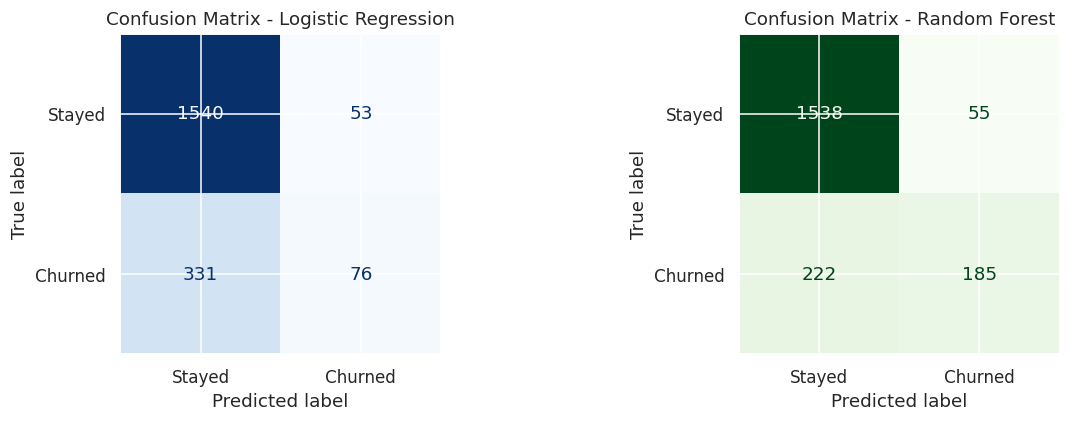

In [16]:
# Side-by-side confusion matrices for model comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay(confusion_matrix(y_test, lr_pred),
    display_labels=['Stayed', 'Churned']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix - Logistic Regression')

ConfusionMatrixDisplay(confusion_matrix(y_test, rf_pred),
    display_labels=['Stayed', 'Churned']).plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Confusion Matrix - Random Forest')

plt.tight_layout()
plt.show()

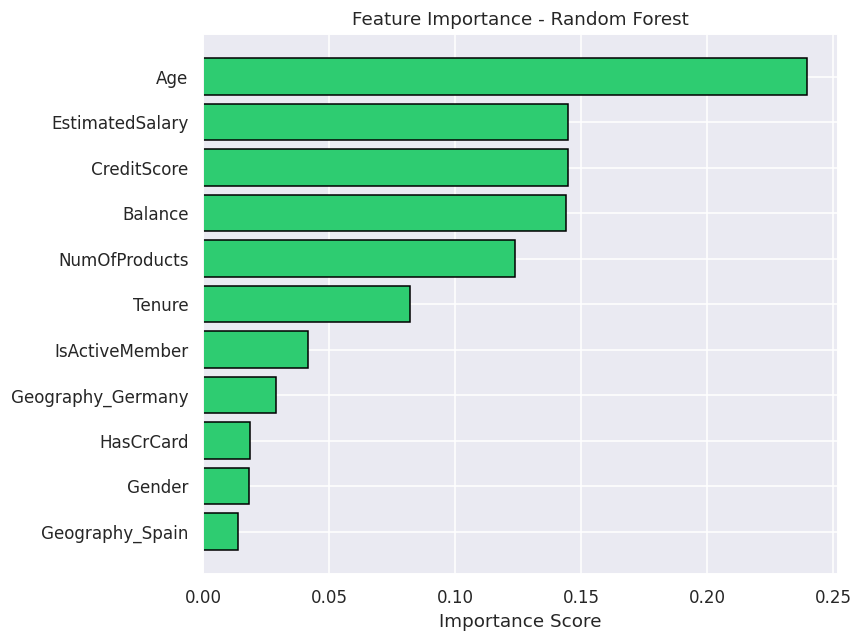

In [17]:
# Bar chart of feature contribution scores - Random Forest
feat_imp = pd.DataFrame({
    'Feature'   : X.columns.tolist(),
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='#2ECC71', edgecolor='black')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

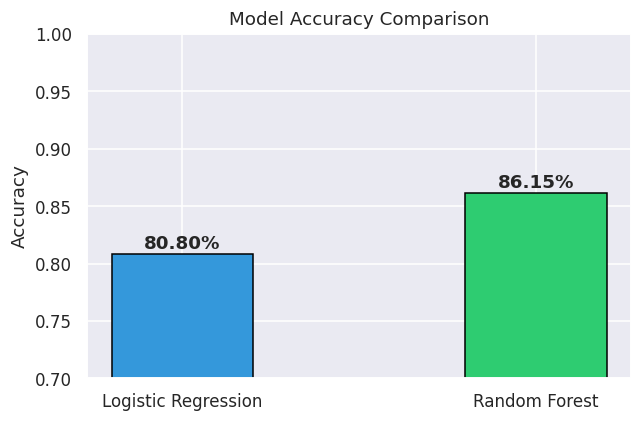

In [18]:
# Visual comparison of model accuracies
plt.figure(figsize=(6, 4))
models     = ['Logistic Regression', 'Random Forest']
accuracies = [lr_acc, rf_acc]
bars = plt.bar(models, accuracies, color=['#3498DB', '#2ECC71'], edgecolor='black', width=0.4)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.7, 1.0)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.005,
             f'{acc:.2%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Step 8: Conclusion

In [19]:
best     = 'Random Forest' if rf_acc >= lr_acc else 'Logistic Regression'
best_acc = max(lr_acc, rf_acc)

print('Model Comparison:')
comparison = pd.DataFrame({
    'Model'   : ['Logistic Regression', 'Random Forest'],
    'Accuracy': [round(lr_acc, 4), round(rf_acc, 4)]
})
print(comparison.to_string(index=False))

print(f'\nBetter Model: {best} with accuracy of {best_acc:.2%}')
print('\nKey Findings:')
print('  - Age is the most important feature — older customers churn more.')
print('  - Customers from Germany have a higher churn rate than France and Spain.')
print('  - Customers with higher balance but fewer products are more likely to churn.')
print('  - Gender encoding and one-hot encoding of Geography improved model performance.')
print('  - Random Forest outperforms Logistic Regression due to its ability to capture non-linear patterns.')

Model Comparison:
              Model  Accuracy
Logistic Regression    0.8080
      Random Forest    0.8615

Better Model: Random Forest with accuracy of 86.15%

Key Findings:
  - Age is the most important feature — older customers churn more.
  - Customers from Germany have a higher churn rate than France and Spain.
  - Customers with higher balance but fewer products are more likely to churn.
  - Gender encoding and one-hot encoding of Geography improved model performance.
  - Random Forest outperforms Logistic Regression due to its ability to capture non-linear patterns.
